In [1]:
import pandas as pd
pd.set_option('display.max_columns', 10)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, HTML
import re
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.neighbors import NearestNeighbors
from nltk.tokenize import sent_tokenize
from sklearn.pipeline import Pipeline
import joblib

In [2]:
df = pd.read_parquet('books.parquet')
df.shape

data = df.copy()

In [3]:
#info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            52478 non-null  str    
 1   title             52478 non-null  str    
 2   series            23470 non-null  str    
 3   author            52478 non-null  str    
 4   rating            52478 non-null  float64
 5   description       51140 non-null  str    
 6   language          48672 non-null  str    
 7   isbn              52478 non-null  str    
 8   genres            52478 non-null  str    
 9   characters        52478 non-null  str    
 10  bookFormat        51005 non-null  str    
 11  edition           4955 non-null   str    
 12  pages             50131 non-null  str    
 13  publisher         48782 non-null  str    
 14  publishDate       51598 non-null  str    
 15  firstPublishDate  31152 non-null  str    
 16  awards            52478 non-null  str    
 17  numR

In [4]:
# null values can be seen, let's check
df.isna().sum()

bookId                  0
title                   0
series              29008
author                  0
rating                  0
description          1338
language             3806
isbn                    0
genres                  0
characters              0
bookFormat           1473
edition             47523
pages                2347
publisher            3696
publishDate           880
firstPublishDate    21326
awards                  0
numRatings              0
ratingsByStars          0
likedPercent          622
setting                 0
coverImg              605
bbeScore                0
bbeVotes                0
price               14365
dtype: int64

In [5]:
#head
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,...,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,...,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38


In [6]:
#duplicates by title and author
df.duplicated(subset= [ 'title' , 'author']).sum()

np.int64(88)

In [7]:
#check those duplicates
df[df.duplicated(subset= [ 'title' , 'author'])]

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
2899,9814682-a-song-of-ice-and-fire,A Song of Ice and Fire,A Song of Ice and Fire #1-4,George R.R. Martin,4.63,...,[],https://i.gr-assets.com/images/S/compressed.ph...,1201,16,12.24
4463,7717482-1q84,1Q84,1Q84 #3,"Haruki Murakami, 村上 春樹",3.90,...,['Tokyo (Japan)'],https://i.gr-assets.com/images/S/compressed.ph...,682,9,13.93
6954,15796908-little-women,Little Women,"Little Women #1, part 1",Louisa May Alcott,4.04,...,"['Concord, Massachusetts (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,384,4,4.08
7550,7148787-remember-me,Remember Me,Remember Me #1-3,Christopher Pike,4.13,...,[],https://i.gr-assets.com/images/S/compressed.ph...,353,4,0.85
8364,11872688-vampire-academy,Vampire Academy,Vampire Academy #1-5,Richelle Mead (Goodreads Author),4.64,...,[],https://i.gr-assets.com/images/S/compressed.ph...,298,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
39209,10100352-poderosa,Poderosa,Poderosa #2,Sérgio Klein,3.46,...,[],https://i.gr-assets.com/images/S/compressed.ph...,84,1,NaN
39721,7495652-poderosa,Poderosa,Poderosa #1,Sérgio Klein,3.53,...,[],https://i.gr-assets.com/images/S/compressed.ph...,83,1,24.25
43445,45026598-oblivion,Oblivion,"Lux #1.5, 2.5, 3.5",Jennifer L. Armentrout (Goodreads Author),4.50,...,[],https://i.gr-assets.com/images/S/compressed.ph...,74,1,NaN
49222,33608846-the-world-we-live-in-a-poetry-book-on...,The World We Live In A Poetry Book On Societal...,NaN,Jamell Crouthers,4.33,...,[],https://i.gr-assets.com/images/S/compressed.ph...,44,1,NaN


In [8]:
#drop duplicates
df.drop_duplicates(subset= [ 'title' , 'author'], keep = 'first', inplace = True)

# EDA

In [9]:
# all categorical columns
df.select_dtypes(include = ['str','object']).head(2)

,bookId,title,series,author,description,...,awards,ratingsByStars,setting,coverImg,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,...,['Locus Award Nominee for Best Young Adult Boo...,"['3444695', '1921313', '745221', '171994', '93...","['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",There is a door at the end of a silent corrido...,...,['Bram Stoker Award for Works for Young Reader...,"['1593642', '637516', '222366', '39573', '14526']",['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,7.38


In [10]:
# columns : pages and price are of string types where as it should be numerical,
df['pages'] = pd.to_numeric(df['pages'], errors = 'coerce') #pages will be converted to float
df['price'] = pd.to_numeric(df['price'], errors = 'coerce') #price will be converted to float



In [11]:
# numerical columns
df.select_dtypes(include = ['number']).head(2)



,rating,pages,numRatings,likedPercent,bbeScore,bbeVotes,price
0,4.33,374.0,6376780,96.0,2993816,30516,5.09
1,4.50,870.0,2507623,98.0,2632233,26923,7.38


In [12]:
# Let's plot images of the top 30 books with highest liked percentage

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Highest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent', ascending=False).head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [13]:
# Let's plot images of the top 30 books with lowest likedPercent

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Lowest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent').head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [14]:
df['bookFormat'].value_counts()

bookFormat
Paperback                26731
Hardcover                12251
Kindle Edition            5813
Mass Market Paperback     2564
ebook                     2544
                         ...  
Casebound                    1
audiobook                    1
Bantam New Fiction           1
Gebunden                     1
pamphlet                     1
Name: count, Length: 136, dtype: int64

In [15]:
# plotting 20 most expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Most Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=False).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [16]:
# plotting 20 least expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Least Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=True).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


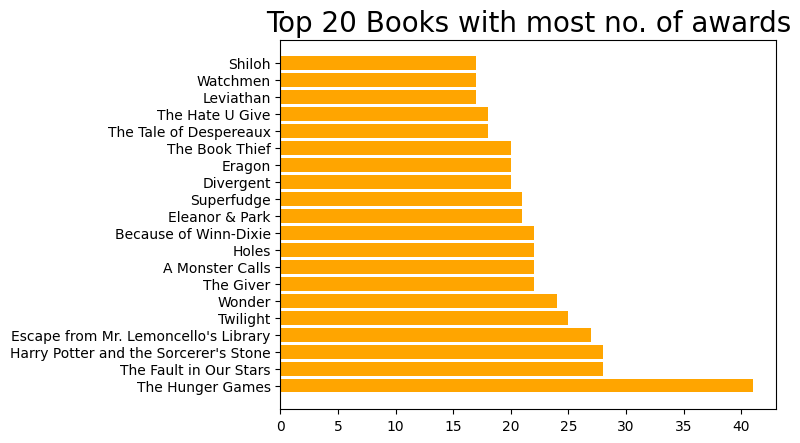

In [17]:
# Get titles and award counts for the top 20 books with most awards
no_of_awards = df['awards'].str.replace('[','').str.replace(']','').str.split(',').apply(lambda lst: len([x.strip() for x in lst if x.strip() != ''])).sort_values(ascending = False).head(20)
ax = plt.barh(width= no_of_awards.values, y = df.loc[no_of_awards.index,'title'], color = 'orange')
plt.plot(figsize = (10,10), ax =ax)
plt.title('Top 20 Books with most no. of awards', size = 20);



In [18]:
df.language.value_counts()

language
English                                  42607
Arabic                                    1036
Spanish                                    684
French                                     576
German                                     525
                                         ...  
Undetermined                                 1
Mayan languages                              1
Duala                                        1
Australian languages                         1
Norwegian Nynorsk; Nynorsk, Norwegian        1
Name: count, Length: 81, dtype: int64

In [19]:
df.characters[0]

"['Katniss Everdeen', 'Peeta Mellark', 'Cato (Hunger Games)', 'Primrose Everdeen', 'Gale Hawthorne', 'Effie Trinket', 'Haymitch Abernathy', 'Cinna', 'President Coriolanus Snow', 'Rue', 'Flavius', 'Lavinia (Hunger Games)', 'Marvel', 'Glimmer', 'Clove', 'Foxface', 'Thresh', 'Greasy Sae', 'Madge Undersee', 'Caesar Flickerman', 'Claudius Templesmith', 'Octavia (Hunger Games)', 'Portia (hunger Games)']"

# Feature Engineering

In [20]:
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,...,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,...,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38


In [21]:
# we will use only few columns
df = df[['title','author','description','genres', 'coverImg']]
df.head()

,title,author,description,genres,coverImg
0,The Hunger Games,Suzanne Collins,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",https://i.gr-assets.com/images/S/compressed.ph...
1,Harry Potter and the Order of the Phoenix,"J.K. Rowling, Mary GrandPré (Illustrator)",There is a door at the end of a silent corrido...,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",https://i.gr-assets.com/images/S/compressed.ph...
2,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"['Classics', 'Fiction', 'Historical Fiction', ...",https://i.gr-assets.com/images/S/compressed.ph...
3,Pride and Prejudice,"Jane Austen, Anna Quindlen (Introduction)",Alternate cover edition of ISBN 9780679783268S...,"['Classics', 'Fiction', 'Romance', 'Historical...",https://i.gr-assets.com/images/S/compressed.ph...
4,Twilight,Stephenie Meyer,About three things I was absolutely positive.\...,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...",https://i.gr-assets.com/images/S/compressed.ph...


In [22]:
#check null values in filtered df
df.isna().sum()

title             0
author            0
description    1334
genres            0
coverImg        603
dtype: int64

In [23]:
#drop null
df.dropna(inplace = True)

In [24]:
#check null again
df.isna().sum()

title          0
author         0
description    0
genres         0
coverImg       0
dtype: int64

In [25]:
df.shape

(50675, 5)

In [26]:
# preprocess genres
df.genres = df.genres.str.lower().str.replace(' ','').apply(eval).str.join(' ') #removing spaces between words

In [27]:
# preprocess author
df['author'] = df['author'].str.replace(' ','').str.replace(',',' ') #removing spaces between name and surname 

df['author'] = df['author'].str.replace(r'\(.+\)','',regex = True).str.replace(r'\s+',' ',regex = True).str.strip() #removing parentheses

df['author'] = df['author'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip() #removing punctuations



In [28]:
# preprocessing description
stop = r'\b('+ '|'.join(stopwords.words('english'))+r')\b'  # stopwords with regex

df['description'] = df['description'].str.lower().str.replace(stop,' ',regex = True) # removing stopwords




In [29]:
#create new column : tags = author + description + genres
df['tags'] = df['author'] + ' ' + df['description'] + ' ' + df['genres']
df.head()

,title,author,description,genres,coverImg,tags
0,The Hunger Games,suzannecollins,winning means fame fortune.losing means cert...,youngadult fiction dystopia fantasy sciencefic...,https://i.gr-assets.com/images/S/compressed.ph...,suzannecollins winning means fame fortune.lo...
1,Harry Potter and the Order of the Phoenix,jkrowling marygrandpr,door end silent corridor. ’ ...,fantasy youngadult fiction magic childrens adv...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowling marygrandpr door end s...
2,To Kill a Mockingbird,harperlee,unforgettable novel childhood sleepy...,classics fiction historicalfiction school lite...,https://i.gr-assets.com/images/S/compressed.ph...,harperlee unforgettable novel childhood ...
3,Pride and Prejudice,janeausten annaquindlen,alternate cover edition isbn 9780679783268si...,classics fiction romance historicalfiction lit...,https://i.gr-assets.com/images/S/compressed.ph...,janeausten annaquindlen alternate cover editio...
4,Twilight,stepheniemeyer,three things absolutely positive.\n\nfir...,youngadult fantasy romance vampires fiction pa...,https://i.gr-assets.com/images/S/compressed.ph...,stepheniemeyer three things absolutely p...


In [30]:
#preprocess tags
df['tags'] = df['tags'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.replace(r'\s+',' ',regex = True).str.strip()  #removing punctuations

In [31]:
#stemming
ps = PorterStemmer()
df['tags'] =df['tags'].str.split(' ').apply(lambda x:[ps.stem(i) for i in x])

df.tags = df.tags.str.join(' ')  # list to text

In [32]:
#tag vectorization
tfidf = TfidfVectorizer(max_features=6000, stop_words = 'english')
vec = tfidf.fit_transform(df['tags']).toarray()

In [33]:
# top 10 similar using nearest neighbors
nn = NearestNeighbors(metric = 'cosine', n_neighbors=10)
nn.fit(vec)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [34]:
_,indices = nn.kneighbors(tfidf.transform([' door end silent corridor haunt harri pottter dream els would wake middl night scream terrorharri lot mind fifth year hogwart defens dark art teacher person like poison honey big surpris gryffindor quidditch team loom terror ordinari wizard level exam thing pale next grow threat must name threat neither magic govern'.lower()]).toarray())

In [35]:
df.iloc[indices.flatten()]

,title,author,description,genres,coverImg,tags
1,Harry Potter and the Order of the Phoenix,jkrowling marygrandpr,door end silent corridor. ’ ...,fantasy youngadult fiction magic childrens adv...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl marygrandpr door end silent corridor ha...
93,Harry Potter and the Prisoner of Azkaban,jkrowling marygrandpr,harry potter' third year hogwarts full ...,fantasy youngadult fiction magic childrens adv...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl marygrandpr harri potter third year hog...
9637,Fantastic Beasts - The Crimes of Grindelwald: ...,jkrowling,"end fantastic beasts find , pow...",fantasy fiction youngadult plays magic adventu...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl end fantast beast find power dark wizar...
103,Harry Potter and the Goblet of Fire,jkrowling marygrandpr,harry potter midway training wizard ...,fantasy youngadult fiction magic childrens adv...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl marygrandpr harri potter midway train w...
40513,The Best Friend,rlstine,best friends… end! honey perkins? ’ ...,horror youngadult fiction childrens thriller m...,https://i.gr-assets.com/images/S/compressed.ph...,rlstine best friend end honey perkin tell ever...
9173,Spellsinger,alandeanfoster,"among sentient animals humans, hardheaded ...",fantasy fiction humor sciencefictionfantasy sc...,https://i.gr-assets.com/images/S/compressed.ph...,alandeanfost among sentient anim human hardhea...
18320,The Wizard of Dark Street,shawnthomasodyssey,"oona crate born wizard’ apprentice, ...",mystery middlegrade fantasy youngadult magic f...,https://i.gr-assets.com/images/S/compressed.ph...,shawnthomasodyssey oona crate born wizard appr...
2580,Harry Potter and the Methods of Rationality,eliezeryudkowsky,harry potter methods rationality wor...,fantasy fiction fanfiction philosophy sciencef...,https://i.gr-assets.com/images/S/compressed.ph...,eliezeryudkowski harri potter method ration wo...
32,Harry Potter and the Sorcerer's Stone,jkrowling marygrandpr,harry potter' life miserable. parents d...,fantasy fiction youngadult magic childrens mid...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl marygrandpr harri potter life miser par...
126,Harry Potter and the Chamber of Secrets,jkrowling marygrandpr,ever since harry potter come home summer...,fantasy youngadult fiction magic childrens mid...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl marygrandpr ever sinc harri potter come...


In [36]:
#creating pipeline
pipeline = Pipeline([
    ('vectorizer', tfidf),
    ('nn', nn)
])

In [37]:
#test pipline
pipeline.named_steps['nn'].kneighbors(
    pipeline.named_steps['vectorizer'].transform(["magic dark fear school magic stick students fairy tale adventure"]),
    return_distance=True
)


(array([[0.60518255, 0.64519266, 0.65028285, 0.65674895, 0.67554096,
         0.6840516 , 0.71680553, 0.72113797, 0.72835305, 0.72840749]]),
 array([[21554, 18539,  6203,  3153,  3548, 47534,  6520, 43440, 35823,
         41040]]))

In [38]:
df.iloc[[21554, 18539,  6203,  3153,  3548, 47534,  6520, 43440, 35823,
         41040]]

,title,author,description,genres,coverImg,tags
21955,The Parchment,sketa,ethan looks onto neighbour' roof top ...,,https://i.gr-assets.com/images/S/compressed.ph...,sketa ethan look onto neighbour roof top find ...
18789,"The Parchment Tale Unfolds,",sketa,part 2 - continuing tale eleven years ol...,,https://i.gr-assets.com/images/S/compressed.ph...,sketa part 2 continu tale eleven year old aust...
6254,The Last Herald-Mage,mercedeslackey,"last herald-mage contains magic' pawn, magi...",fantasy fiction sciencefictionfantasy magic ep...,https://i.gr-assets.com/images/S/compressed.ph...,mercedeslackey last heraldmag contain magic pa...
3171,A Spell for Chameleon,piersanthony,xanth enchanted land magic ruled - eve...,fantasy fiction humor sciencefictionfantasy yo...,https://i.gr-assets.com/images/S/compressed.ph...,piersanthoni xanth enchant land magic rule eve...
3567,White Cat,hollyblack,extraordinary new adult fantasy magic ...,fantasy youngadult urbanfantasy paranormal mag...,https://i.gr-assets.com/images/S/compressed.ph...,hollyblack extraordinari new adult fantasi mag...
49202,Stick,andrewsmith,fourteen-year-old stark mcclellan (nicknamed s...,youngadult lgbt realisticfiction fiction abuse...,https://i.gr-assets.com/images/S/compressed.ph...,andrewsmith fourteenyearold stark mcclellan ni...
6571,False Memory,deankoontz,' fear paralyzing falling. terrifyin...,horror fiction thriller mystery suspense myste...,https://i.gr-assets.com/images/S/compressed.ph...,deankoontz fear paralyz fall terrifi dark horr...
44939,Beware the Wild,nataliecparker,' oppressively hot sticky morning june...,youngadult fantasy paranormal mystery horror r...,https://i.gr-assets.com/images/S/compressed.ph...,nataliecpark oppress hot sticki morn june ster...
36943,A Sliver of Stardust,marissaburt,gold lock. gold key.however high ...,fantasy middlegrade adventure magic childrens ...,https://i.gr-assets.com/images/S/compressed.ph...,marissaburt gold lock gold keyhowev high low h...
42438,Mother Knows Best,serenavalentino,tale rapunzel widely known. old ...,fantasy retellings youngadult fiction fairytal...,https://i.gr-assets.com/images/S/compressed.ph...,serenavalentino tale rapunzel wide known old w...


In [39]:
#dump model
# joblib.dump(pipeline,'book_recommender.HDF5', compress=9)   #using compression because of large size